# Collecte de Données — Tier 2 : Sources Externes
## Projet ValuSense — Enrichissement par OpenFIGI, yfinance élargi, FinanceDatabase, ECB

**Objectif :** Collecter des données d'instruments financiers réels depuis des sources gratuites pour :
1. **Diversifier** les profils d'actifs (obligations, options, swaps, futures)
2. **Enrichir** le dataset synthétique avec des features numériques réalistes
3. **Valider** les règles expertes contre des instruments de marché réels

**Sources couvertes dans ce notebook :**

| Source | Type de données | Accès | Classes d'actifs |
|---|---|---|---|
| **OpenFIGI** | Métadonnées instruments (type, bourse, secteur) | API REST gratuite | Toutes |
| **yfinance élargi** | Prix, fondamentaux, options chains | Python package | Equity, Option, Commodity, Currency |
| **FinanceDatabase** | Catalogue 353K instruments + métadonnées | Python package | Toutes |
| **ECB / Banque Mondiale** | Taux souverains, indicateurs économiques | API REST | Bond, Currency |
| **FRED étendu** | Séries macro supplémentaires | API Python | Bond, Derivative |

**Temps estimé :** 30-60 minutes (collecte API + sauvegarde)


---
## 0. Configuration


In [1]:
import pandas as pd
import numpy as np
import os
import time
import warnings
import json as json_lib
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

warnings.filterwarnings("ignore")

DATA_ROOT = Path("data_valuation_project")

# Créer les sous-dossiers de sortie
for subdir in [
    "raw/equities_ext", "raw/options_ext", "raw/bonds_ext",
    "raw/macro_ext", "raw/openfigi", "raw/ecb",
    "catalogs", "processed"
]:
    (DATA_ROOT / subdir).mkdir(parents=True, exist_ok=True)

print(f"Repertoire racine : {DATA_ROOT.resolve()}")
print(f"Date de collecte  : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Repertoire racine : C:\Users\MSI\Desktop\Stage ingénieur - VERMEG\python project\data_valuation_project
Date de collecte  : 2026-07-02 10:10


---
## 1. OpenFIGI — Métadonnées d'Instruments Réels

L'API OpenFIGI fournit un identifiant unique (FIGI) pour chaque instrument financier et retourne des métadonnées structurées : `securityType`, `marketSector`, `exchCode`, `securityType2`.

- **Gratuit**, sans limite quotidienne avec clé API
- Couvre **toutes les classes d'actifs** : actions, obligations, options, futures, swaps, devises
- Licence MIT (open data)

Nous utilisons l'endpoint `/v3/search` pour récupérer des instruments par type.


In [10]:
import requests
import time
import os

OPENFIGI_BASE = "https://api.openfigi.com/v3"
OPENFIGI_API_KEY = ""  # optionnel — créer un compte sur openfigi.com

HEADERS = {"Content-Type": "application/json"}
if OPENFIGI_API_KEY:
    HEADERS["X-OPENFIGI-APIKEY"] = OPENFIGI_API_KEY


def _pause():
    """Pause adaptative selon le mode authentifié ou non."""
    if OPENFIGI_API_KEY:
        time.sleep(3.5)   # 20 req/min avec clé
    else:
        time.sleep(13)    # 5 req/min sans clé


# ─── APPROCHE 1 : /v3/search (recherche par mots-clés) ───────
def openfigi_search(query, **filters):
    """
    POST /v3/search — recherche par mots-clés.
    Filtres optionnels : exchCode, marketSecDes, securityType, securityType2
    Retourne une liste de dicts d'instruments.
    """
    payload = {"query": query}
    payload.update(filters)

    try:
        r = requests.post(f"{OPENFIGI_BASE}/search", json=payload, headers=HEADERS, timeout=15)
        if r.status_code == 200:
            body = r.json()
            return body.get("data", [])
        elif r.status_code == 429:
            print(f"    Rate limit — pause 60s")
            time.sleep(60)
            return openfigi_search(query, **filters)
        else:
            print(f"    /search erreur {r.status_code}: {r.text[:200]}")
            return []
    except Exception as e:
        print(f"    /search exception: {e}")
        return []


# ─── APPROCHE 2 : /v3/mapping (mapping par identifiant) ──────
def openfigi_map(jobs):
    """
    POST /v3/mapping — mapper des identifiants connus vers FIGI.
    jobs = liste de dicts, ex: [{"idType": "TICKER", "idValue": "IBM", "exchCode": "US"}]
    Max 10 jobs sans clé, 100 avec clé.
    """
    try:
        r = requests.post(f"{OPENFIGI_BASE}/mapping", json=jobs, headers=HEADERS, timeout=15)
        if r.status_code == 200:
            results = []
            for item in r.json():
                if "data" in item:
                    results.extend(item["data"])
            return results
        elif r.status_code == 429:
            print(f"    Rate limit — pause 60s")
            time.sleep(60)
            return openfigi_map(jobs)
        else:
            print(f"    /mapping erreur {r.status_code}: {r.text[:200]}")
            return []
    except Exception as e:
        print(f"    /mapping exception: {e}")
        return []


# ─── APPROCHE 3 : /v3/filter (filtrage par propriétés) ────────
def openfigi_filter(**filters):
    """
    POST /v3/filter — filtrer par propriétés (marketSecDes, securityType, exchCode...).
    marketSecDes valides : Comdty, Corp, Curncy, Equity, Govt, Index, M-Mkt, Mtge, Muni, Pfd
    """
    try:
        r = requests.post(f"{OPENFIGI_BASE}/filter", json=filters, headers=HEADERS, timeout=15)
        if r.status_code == 200:
            body = r.json()
            return body.get("data", [])
        elif r.status_code == 429:
            print(f"    Rate limit — pause 60s")
            time.sleep(60)
            return openfigi_filter(**filters)
        else:
            print(f"    /filter erreur {r.status_code}: {r.text[:200]}")
            return []
    except Exception as e:
        print(f"    /filter exception: {e}")
        return []


print("Fonctions OpenFIGI v3 pretes (search / mapping / filter).")

Fonctions OpenFIGI v3 pretes (search / mapping / filter).


In [12]:
# ═══════════════════════════════════════════════════════════════
# COLLECTE OPENFIGI — 3 APPROCHES COMBINÉES
# ═══════════════════════════════════════════════════════════════
all_instruments = []

def _append(items, category, source):
    """Ajoute les résultats au pool global."""
    for item in items:
        all_instruments.append({
            "figi": item.get("figi", ""),
            "name": item.get("name", ""),
            "ticker": item.get("ticker", ""),
            "security_type": item.get("securityType", ""),
            "security_type2": item.get("securityType2", ""),
            "market_sector": item.get("marketSector", ""),
            "exchange": item.get("exchCode", ""),
            "search_category": category,
            "search_source": source,
        })


# ─── APPROCHE 1 : /v3/mapping — instruments connus par ticker ─
print("=" * 65)
print("  APPROCHE 1 : /v3/mapping (tickers connus)")
print("=" * 65)

# Batch 1 : Actions (TICKER + exchCode)
equity_jobs = [
    {"idType": "TICKER", "idValue": t, "exchCode": "US"}
    for t in ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA",
              "JPM", "BAC", "GS", "JNJ", "PFE", "XOM", "WMT", "KO"]
]
# Batch limité à 10 sans clé API, 100 avec clé
batch_size = 100 if OPENFIGI_API_KEY else 10

for i in range(0, len(equity_jobs), batch_size):
    batch = equity_jobs[i:i+batch_size]
    results = openfigi_map(batch)
    _append(results, "Equity", "mapping")
    print(f"  Equities batch {i//batch_size + 1}: {len(results)} instruments")
    _pause()

# Batch 2 : Obligations corporate (BASE_TICKER + marketSecDes)
bond_jobs = [
    {"idType": "BASE_TICKER", "idValue": name, "marketSecDes": "Corp"}
    for name in ["AAPL", "MSFT", "AMZN", "JPM", "GS", "T", "VZ", "IBM", "BA", "CAT"]
]
for i in range(0, len(bond_jobs), batch_size):
    batch = bond_jobs[i:i+batch_size]
    results = openfigi_map(batch)
    _append(results, "Bond", "mapping")
    print(f"  Corp bonds batch {i//batch_size + 1}: {len(results)} instruments")
    _pause()

# Batch 3 : Obligations souveraines (BASE_TICKER + marketSecDes=Govt)
govt_jobs = [
    {"idType": "BASE_TICKER", "idValue": name, "marketSecDes": "Govt"}
    for name in ["T", "DBR", "OAT", "BTPS", "UKT", "JGB", "ACGB"]
]
results = openfigi_map(govt_jobs)
_append(results, "Bond", "mapping")
print(f"  Govt bonds: {len(results)} instruments")
_pause()

# Batch 4 : Munis
muni_jobs = [{"idType": "BASE_TICKER", "idValue": "NY", "marketSecDes": "Muni"}]
results = openfigi_map(muni_jobs)
_append(results, "Bond", "mapping")
print(f"  Munis: {len(results)} instruments")
_pause()


# ─── APPROCHE 2 : /v3/search — recherche par mots-clés ────────
print("\n" + "=" * 65)
print("  APPROCHE 2 : /v3/search (mots-cles)")
print("=" * 65)

search_queries = [
    # Obligations
    ("US TREASURY", {}),
    ("FRANCE OAT", {}),
    ("APPLE", {"marketSecDes": "Corp"}),
    ("MICROSOFT", {"marketSecDes": "Corp"}),
    ("HIGH YIELD BOND", {}),
    ("CONVERTIBLE", {"marketSecDes": "Corp"}),

    # Futures / Commodities
    ("CRUDE OIL", {"marketSecDes": "Comdty"}),
    ("GOLD", {"marketSecDes": "Comdty"}),
    ("NATURAL GAS", {"marketSecDes": "Comdty"}),
    ("CORN", {"marketSecDes": "Comdty"}),
    ("COPPER", {"marketSecDes": "Comdty"}),

    # Devises
    ("EUR", {"marketSecDes": "Curncy"}),
    ("GBP", {"marketSecDes": "Curncy"}),
    ("JPY", {"marketSecDes": "Curncy"}),

    # Preferred stocks
    ("PREFERRED", {"marketSecDes": "Pfd"}),

    # Mortgage
    ("MORTGAGE", {"marketSecDes": "Mtge"}),

    # Money Market
    ("TREASURY BILL", {"marketSecDes": "M-Mkt"}),
]

category_map = {
    "Corp": "Bond", "Govt": "Bond", "Muni": "Bond", "Mtge": "Bond",
    "Comdty": "Commodity", "Curncy": "Currency",
    "Equity": "Equity", "Pfd": "Equity", "Index": "Derivative",
    "M-Mkt": "Bond",
}

for query, filters in search_queries:
    results = openfigi_search(query, **filters)
    msd = filters.get("marketSecDes", "")
    cat = category_map.get(msd, "Bond")
    _append(results, cat, "search")
    
    # Correction: On force la conversion du dictionnaire en string avant de formater la largeur
    filter_str = str(filters) if filters else ""
    print(f"  '{query}' {filter_str:<35} -> {len(results)} resultats")
    _pause()
# ─── APPROCHE 3 : /v3/filter — par secteur de marché ──────────
print("\n" + "=" * 65)
print("  APPROCHE 3 : /v3/filter (par secteur)")
print("=" * 65)

# marketSecDes valides : Comdty, Corp, Curncy, Equity, Govt, Index, M-Mkt, Mtge, Muni, Pfd
filter_sectors = [
    ("Govt",   "Bond"),
    ("Corp",   "Bond"),
    ("Muni",   "Bond"),
    ("Comdty", "Commodity"),
    ("Curncy", "Currency"),
    ("Pfd",    "Equity"),
    ("Mtge",   "Bond"),
    ("M-Mkt",  "Bond"),
    ("Index",  "Derivative"),
]

for sector, category in filter_sectors:
    results = openfigi_filter(marketSecDes=sector)
    _append(results, category, "filter")
    print(f"  marketSecDes='{sector}' -> {len(results)} resultats")
    _pause()

# Filtres croisés pour plus de diversité
cross_filters = [
    ({"marketSecDes": "Equity", "exchCode": "US"}, "Equity"),
    ({"marketSecDes": "Equity", "exchCode": "LN"}, "Equity"),
    ({"marketSecDes": "Equity", "exchCode": "JP"}, "Equity"),
    ({"marketSecDes": "Equity", "exchCode": "GR"}, "Equity"),
    ({"marketSecDes": "Corp", "currency": "EUR"}, "Bond"),
    ({"marketSecDes": "Corp", "currency": "GBP"}, "Bond"),
    ({"marketSecDes": "Govt", "currency": "EUR"}, "Bond"),
]

for filt, category in cross_filters:
    results = openfigi_filter(**filt)
    _append(results, category, "filter")
    desc = " + ".join(f"{k}={v}" for k, v in filt.items())
    print(f"  {desc} -> {len(results)} resultats")
    _pause()


# ─── RÉSULTAT FINAL ───────────────────────────────────────────
print("\n" + "=" * 65)
print("  RÉSULTAT FINAL")
print("=" * 65)

if all_instruments:
    df_figi = pd.DataFrame(all_instruments)
    df_figi = df_figi.drop_duplicates(subset=["figi"]).reset_index(drop=True)
else:
    cols = ["figi", "name", "ticker", "security_type", "security_type2",
            "market_sector", "exchange", "search_category", "search_source"]
    df_figi = pd.DataFrame(columns=cols)

output_path = DATA_ROOT / "raw/openfigi/openfigi_instruments.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
df_figi.to_csv(output_path, index=False)

print(f"Total instruments uniques : {len(df_figi)}")
print(f"Sauvegarde : {output_path}")

if not df_figi.empty:
    print(f"\nPar source de collecte :")
    print(df_figi["search_source"].value_counts().to_string())
    print(f"\nPar categorie :")
    print(df_figi["search_category"].value_counts().to_string())
    print(f"\nPar secteur de marche (top 10) :")
    print(df_figi["market_sector"].value_counts().head(10).to_string())
    print(f"\nPar type de securite (top 15) :")
    print(df_figi["security_type"].value_counts().head(15).to_string())
else:
    print("\nAucun resultat — verifier la connexion et le rate limit.")
    print("Conseil : creer un compte gratuit sur openfigi.com pour obtenir une cle API.")

  APPROCHE 1 : /v3/mapping (tickers connus)
  Equities batch 1: 10 instruments
  Equities batch 2: 4 instruments
  Corp bonds batch 1: 0 instruments
  Govt bonds: 0 instruments
  Munis: 0 instruments

  APPROCHE 2 : /v3/search (mots-cles)
  'US TREASURY'                                     -> 100 resultats
  'FRANCE OAT'                                     -> 100 resultats
  'APPLE' {'marketSecDes': 'Corp'}            -> 100 resultats
  'MICROSOFT' {'marketSecDes': 'Corp'}            -> 87 resultats
  'HIGH YIELD BOND'                                     -> 100 resultats
  'CONVERTIBLE' {'marketSecDes': 'Corp'}            -> 19 resultats
  'CRUDE OIL' {'marketSecDes': 'Comdty'}          -> 100 resultats
  'GOLD' {'marketSecDes': 'Comdty'}          -> 100 resultats
  'NATURAL GAS' {'marketSecDes': 'Comdty'}          -> 100 resultats
  'CORN' {'marketSecDes': 'Comdty'}          -> 100 resultats
  'COPPER' {'marketSecDes': 'Comdty'}          -> 100 resultats
  'EUR' {'marketSecDes': 'Curn

### 1.1 Conversion OpenFIGI → Format Labellisé

Mapper les métadonnées OpenFIGI vers notre schéma de 15 features + variable cible en appliquant les règles expertes.


In [14]:
def figi_to_labeled_row(row):
    """Convertit une ligne OpenFIGI en format labellisé ValuSense."""
    sec_type = str(row.get("security_type", "")).lower()
    sec_type2 = str(row.get("security_type2", "")).lower()
    market = str(row.get("market_sector", "")).lower()   # "govt", "corp", "equity", etc.
    category = str(row.get("search_category", ""))       # ce qu'on a assigné pendant la collecte
    exchange = str(row.get("exchange", ""))
    has_exchange = 1 if exchange and exchange not in ["", "nan", "OTC", "nan"] else 0

    # ── Priorité 1 : utiliser market_sector (le champ le plus fiable d'OpenFIGI)
    # Valeurs possibles : govt, corp, equity, comdty, curncy, index, m-mkt, mtge, muni, pfd

    # ── Obligations Souveraines ───────────────────────────────
    if market == "govt" or (category == "Bond" and "govt" in sec_type):
        return _make_bond("Government Bond", has_exchange,
                          is_credit=0, liq=["High", "Medium"], ifrs=[1, 2],
                          data=["Full", "Partial"], method="DCF")

    # ── Obligations Corporate ─────────────────────────────────
    if market == "corp" or (category == "Bond" and any(k in sec_type for k in ["corp", "debenture"])):
        is_hy = any(k in sec_type for k in ["high yield", " hy", "junk"])
        is_convert = "convert" in sec_type

        if is_convert:
            return {
                "asset_class": "Bond", "asset_subclass": "Convertible Bond",
                "has_market_price": has_exchange, "has_cash_flows": 1,
                "has_options_features": 1, "is_exchange_traded": has_exchange,
                "has_credit_risk": 1, "has_early_exercise": 1,
                "is_path_dependent": 0, "volatility_available": 1,
                "liquidity": np.random.choice(["Medium", "Low"]),
                "maturity_years": round(np.random.uniform(3, 10), 2),
                "data_availability": "Partial",
                "ifrs_level": np.random.choice([2, 3]),
                "recommended_method": "Binomial-Tree",
            }
        if is_hy:
            return _make_bond("Corporate Bond (HY)", has_exchange,
                              is_credit=1, liq=["Medium", "Low"], ifrs=[2, 3],
                              data=["Partial", "Sparse"], method="Credit-Model")

        return _make_bond("Corporate Bond (IG)", has_exchange,
                          is_credit=1, liq=["High", "Medium"], ifrs=[1, 2],
                          data=["Full", "Partial"], method="DCF")

    # ── Obligations Municipales ───────────────────────────────
    if market == "muni":
        return _make_bond("Municipal Bond", 0,
                          is_credit=1, liq=["Low", "Medium"], ifrs=[2, 3],
                          data=["Partial", "Sparse"], method="DCF")

    # ── Mortgage-Backed Securities ────────────────────────────
    if market == "mtge":
        return _make_bond("MBS", 0,
                          is_credit=1, liq=["Medium", "Low"], ifrs=[2, 3],
                          data=["Partial", "Sparse"], method="DCF")

    # ── Money Market ──────────────────────────────────────────
    if market == "m-mkt":
        return _make_bond("Treasury Bill", 1,
                          is_credit=0, liq=["High"], ifrs=[1],
                          data=["Full"], method="DCF",
                          mat_range=(0.02, 1))

    # ── Actions ───────────────────────────────────────────────
    if market == "equity" or category == "Equity" or "stock" in sec_type:
        return _make_equity(sec_type, has_exchange)

    # ── Preferred Stock ───────────────────────────────────────
    if market == "pfd" or "prefer" in sec_type:
        return {
            "asset_class": "Equity", "asset_subclass": "Preferred Stock",
            "has_market_price": 1, "has_cash_flows": 1,
            "has_options_features": 0, "is_exchange_traded": 1,
            "has_credit_risk": 0, "has_early_exercise": 0,
            "is_path_dependent": 0, "volatility_available": 1,
            "liquidity": np.random.choice(["Medium", "Medium", "High"]),
            "maturity_years": np.nan,
            "data_availability": np.random.choice(["Full", "Partial"]),
            "ifrs_level": np.random.choice([1, 2]),
            "recommended_method": "DDM",
        }

    # ── Index ─────────────────────────────────────────────────
    if market == "index":
        return {
            "asset_class": "Equity", "asset_subclass": "Index",
            "has_market_price": 1, "has_cash_flows": 0,
            "has_options_features": 0, "is_exchange_traded": 1,
            "has_credit_risk": 0, "has_early_exercise": 0,
            "is_path_dependent": 0, "volatility_available": 1,
            "liquidity": "High",
            "maturity_years": np.nan,
            "data_availability": "Full",
            "ifrs_level": 1,
            "recommended_method": "Mark-to-Market",
        }

    # ── Commodities ───────────────────────────────────────────
    if market == "comdty" or category == "Commodity":
        return {
            "asset_class": "Commodity", "asset_subclass": "Commodity Spot",
            "has_market_price": 1, "has_cash_flows": 0,
            "has_options_features": 0, "is_exchange_traded": 1,
            "has_credit_risk": 0, "has_early_exercise": 0,
            "is_path_dependent": 0, "volatility_available": 1,
            "liquidity": np.random.choice(["High", "Medium"]),
            "maturity_years": round(np.random.uniform(0.1, 2), 2),
            "data_availability": "Full",
            "ifrs_level": 1,
            "recommended_method": "Cost-of-Carry",
        }

    # ── Devises ───────────────────────────────────────────────
    if market == "curncy" or category == "Currency":
        return {
            "asset_class": "Currency", "asset_subclass": "FX Forward",
            "has_market_price": 1, "has_cash_flows": 0,
            "has_options_features": 0, "is_exchange_traded": 0,
            "has_credit_risk": 0, "has_early_exercise": 0,
            "is_path_dependent": 0, "volatility_available": 1,
            "liquidity": np.random.choice(["High", "High", "Medium"]),
            "maturity_years": round(np.random.uniform(0.02, 1), 2),
            "data_availability": "Full",
            "ifrs_level": np.random.choice([1, 2]),
            "recommended_method": "Forward-Pricing",
        }

    # ── Options / Warrants ────────────────────────────────────
    if category == "Option" or "option" in sec_type or "warrant" in sec_type:
        is_american = np.random.random() < 0.4
        return {
            "asset_class": "Option",
            "asset_subclass": "American Option" if is_american else "European Option",
            "has_market_price": has_exchange, "has_cash_flows": 0,
            "has_options_features": 1, "is_exchange_traded": has_exchange,
            "has_credit_risk": 0,
            "has_early_exercise": 1 if is_american else 0,
            "is_path_dependent": 0, "volatility_available": 1,
            "liquidity": np.random.choice(["High", "Medium"]),
            "maturity_years": round(np.random.uniform(0.02, 2), 2),
            "data_availability": np.random.choice(["Full", "Partial"]),
            "ifrs_level": np.random.choice([1, 2]),
            "recommended_method": "Binomial-Tree" if is_american else "Black-Scholes",
        }

    # ── Dérivés (swaps, futures, forwards) ────────────────────
    if category == "Derivative" or "swap" in sec_type or "future" in sec_type or "forward" in sec_type:
        is_cds = "credit" in sec_type or (category == "Derivative" and "credit" in str(row.get("name", "")).lower())
        is_future = "future" in sec_type

        if is_cds:
            return {
                "asset_class": "Bond", "asset_subclass": "CDS",
                "has_market_price": 0, "has_cash_flows": 1,
                "has_options_features": 0, "is_exchange_traded": 0,
                "has_credit_risk": 1, "has_early_exercise": 0,
                "is_path_dependent": 0, "volatility_available": 0,
                "liquidity": np.random.choice(["Medium", "Low"]),
                "maturity_years": round(np.random.uniform(1, 10), 2),
                "data_availability": np.random.choice(["Partial", "Sparse"]),
                "ifrs_level": np.random.choice([2, 3]),
                "recommended_method": "Credit-Model",
            }
        if is_future:
            return {
                "asset_class": "Derivative", "asset_subclass": "Future",
                "has_market_price": 1, "has_cash_flows": 0,
                "has_options_features": 0, "is_exchange_traded": 1,
                "has_credit_risk": 0, "has_early_exercise": 0,
                "is_path_dependent": 0, "volatility_available": 1,
                "liquidity": np.random.choice(["High", "Medium"]),
                "maturity_years": round(np.random.uniform(0.1, 2), 2),
                "data_availability": "Full",
                "ifrs_level": np.random.choice([1, 2]),
                "recommended_method": np.random.choice(["Forward-Pricing", "Cost-of-Carry"]),
            }
        # IRS ou autre swap
        return {
            "asset_class": "Derivative", "asset_subclass": "Interest Rate Swap",
            "has_market_price": 0, "has_cash_flows": 1,
            "has_options_features": 0, "is_exchange_traded": 0,
            "has_credit_risk": 1, "has_early_exercise": 0,
            "is_path_dependent": 0, "volatility_available": 0,
            "liquidity": np.random.choice(["Medium", "High"]),
            "maturity_years": round(np.random.uniform(1, 30), 2),
            "data_availability": np.random.choice(["Partial", "Full"]),
            "ifrs_level": 2,
            "recommended_method": "DCF",
        }

    return None  # instrument non mappable


# ── Fonctions helper ──────────────────────────────────────────

def _make_bond(subclass, has_exchange, is_credit, liq, ifrs, data, method, mat_range=(2, 30)):
    """Helper pour générer une ligne Bond."""
    return {
        "asset_class": "Bond", "asset_subclass": subclass,
        "has_market_price": 1 if has_exchange else 0,
        "has_cash_flows": 1,
        "has_options_features": 0,
        "is_exchange_traded": has_exchange,
        "has_credit_risk": is_credit,
        "has_early_exercise": 0,
        "is_path_dependent": 0,
        "volatility_available": 1 if has_exchange else 0,
        "liquidity": np.random.choice(liq),
        "maturity_years": round(np.random.uniform(*mat_range), 2),
        "data_availability": np.random.choice(data),
        "ifrs_level": np.random.choice(ifrs),
        "recommended_method": method,
    }


def _make_equity(sec_type, has_exchange):
    """Helper pour générer une ligne Equity."""
    if "etf" in sec_type:
        return {
            "asset_class": "Equity", "asset_subclass": "ETF (Equity)",
            "has_market_price": 1, "has_cash_flows": 0,
            "has_options_features": 0, "is_exchange_traded": 1,
            "has_credit_risk": 0, "has_early_exercise": 0,
            "is_path_dependent": 0, "volatility_available": 1,
            "liquidity": "High", "maturity_years": np.nan,
            "data_availability": "Full", "ifrs_level": 1,
            "recommended_method": "Mark-to-Market",
        }
    if "reit" in sec_type:
        subclass = "REIT"
        method = "DDM"
    elif "adr" in sec_type:
        subclass = "ADR"
        method = np.random.choice(["Relative", "DCF"])
    else:
        subclass = np.random.choice(["Large Cap Dividend", "Large Cap Growth", "Mid Cap"])
        method = np.random.choice(["Mark-to-Market", "Relative", "DDM", "DCF"])

    return {
        "asset_class": "Equity", "asset_subclass": subclass,
        "has_market_price": 1, "has_cash_flows": 1,
        "has_options_features": 0, "is_exchange_traded": 1,
        "has_credit_risk": 0, "has_early_exercise": 0,
        "is_path_dependent": 0, "volatility_available": 1,
        "liquidity": np.random.choice(["High", "High", "Medium"]),
        "maturity_years": np.nan,
        "data_availability": np.random.choice(["Full", "Full", "Partial"]),
        "ifrs_level": 1,
        "recommended_method": method,
    }


print("Fonctions de mapping pretes.")

Fonctions de mapping pretes.


In [15]:
# ── Appliquer la conversion ────────────────────────────────────
np.random.seed(42)

labeled_from_figi = []
skipped = 0
skip_reasons = {}

for _, row in df_figi.iterrows():
    result = figi_to_labeled_row(row)
    if result:
        labeled_from_figi.append(result)
    else:
        skipped += 1
        # Diagnostiquer pourquoi l'instrument n'a pas été mappé
        key = f"market={row.get('market_sector','?')} | cat={row.get('search_category','?')}"
        skip_reasons[key] = skip_reasons.get(key, 0) + 1

df_figi_labeled = pd.DataFrame(labeled_from_figi)

print(f"Instruments convertis : {len(df_figi_labeled)}")
print(f"Instruments ignores   : {skipped}")

if skip_reasons:
    print(f"\nRaisons des instruments ignores :")
    for reason, count in sorted(skip_reasons.items(), key=lambda x: -x[1]):
        print(f"   {reason} : {count}")

if not df_figi_labeled.empty:
    print(f"\nDistribution par methode :")
    print(df_figi_labeled["recommended_method"].value_counts().to_string())
    print(f"\nDistribution par classe :")
    print(df_figi_labeled["asset_class"].value_counts().to_string())
    print(f"\nDistribution par sous-classe :")
    print(df_figi_labeled["asset_subclass"].value_counts().to_string())

    # Sauvegarder
    figi_output = DATA_ROOT / "processed/labeled_from_openfigi.csv"
    df_figi_labeled.to_csv(figi_output, index=False)
    print(f"\nSauvegarde : {figi_output}")
else:
    print("\nAucun instrument converti — verifier df_figi ci-dessus.")

Instruments convertis : 3106
Instruments ignores   : 0

Distribution par methode :
recommended_method
DCF                1464
Cost-of-Carry       600
Forward-Pricing     402
Mark-to-Market      282
DDM                 181
Relative            177

Distribution par classe :
asset_class
Bond         1286
Equity        818
Commodity     600
Currency      402

Distribution par sous-classe :
asset_subclass
Commodity Spot         600
Corporate Bond (IG)    495
FX Forward             402
Government Bond        390
Large Cap Growth       245
Large Cap Dividend     239
Mid Cap                220
MBS                    200
Index                  114
Treasury Bill          101
Municipal Bond         100

Sauvegarde : data_valuation_project\processed\labeled_from_openfigi.csv


---
## 2. FinanceDatabase — Exploitation Élargie du Catalogue

Le catalogue existant (353K instruments) contient des métadonnées riches (secteur, industrie, pays, type) qui permettent de générer des profils labellisés réalistes.

Nous allons parcourir le catalogue et créer des échantillons labellisés pour chaque type d'instrument identifié.


In [16]:
# ── Charger le catalogue ───────────────────────────────────────
catalog_path = DATA_ROOT / "catalogs/full_instrument_catalog.csv"
catalog = pd.read_csv(catalog_path, low_memory=False)

print(f"Catalogue : {len(catalog):,} instruments x {catalog.shape[1]} colonnes")
print(f"Colonnes  : {list(catalog.columns)}")

# Identifier les types d'instruments
type_cols = [c for c in catalog.columns if any(k in c.lower() for k in ["type", "category", "summary"])]
if type_cols:
    for tc in type_cols:
        print(f"\n{tc} :")
        print(catalog[tc].value_counts().head(20).to_string())

Catalogue : 353,749 instruments x 18 colonnes
Colonnes  : ['symbol', 'name', 'currency', 'sector', 'industry_group', 'industry', 'exchange', 'market', 'country', 'market_cap', 'asset_class', 'asset_subclass', 'category_group', 'category', 'base_currency', 'quote_currency', 'cryptocurrency', 'family']

category_group :
category_group
Equities                  26023
Fixed Income              20895
Financials                13308
Alternatives               7715
Real Estate                1811
Information Technology     1635
Commodities                1161
Derivatives                 820
Health Care                 716
Energy                      708
Target Date                 633
Industrials                 517
Cash                        476
Materials                   400
Consumer Discretionary      305
Utilities                   253
Miscellaneous               247
Currencies                  202
Consumer Staples            186
Communication Services      182

category :
category
Deve

In [17]:
def catalog_to_labeled(catalog_df, n_per_type=50):
    """
    Échantillonne des instruments du catalogue et les convertit
    en lignes labellisées via règles expertes.
    """
    np.random.seed(42)
    rows = []

    # Identifier la colonne type
    type_col = None
    for c in ["summary_type", "type", "category", "instrument_type"]:
        if c in catalog_df.columns:
            type_col = c
            break

    if type_col is None:
        print("Colonne de type non trouvee — utilisation du nom comme proxy")
        return pd.DataFrame()

    type_map = catalog_df[type_col].value_counts()

    for instrument_type, count in type_map.items():
        it = str(instrument_type).lower()
        sample_n = min(n_per_type, count)
        sample = catalog_df[catalog_df[type_col] == instrument_type].sample(sample_n, random_state=42)

        for _, inst in sample.iterrows():
            country = str(inst.get("country", "")).lower()
            sector = str(inst.get("sector", "")).lower()
            has_div = "dividend" in sector or "utilities" in sector or "consumer" in sector

            # ETF → Mark-to-Market
            if "etf" in it:
                rows.append(_make_row("Equity", "ETF (Equity)", "Mark-to-Market",
                                      has_mp=1, has_cf=0, exchange=1, liq="High", ifrs=1))

            # Fund → DCF ou Mark-to-Market
            elif "fund" in it or "mutual" in it:
                rows.append(_make_row("Equity", "Fund", "Mark-to-Market",
                                      has_mp=1, has_cf=0, exchange=1, liq="High", ifrs=1))

            # Index → Mark-to-Market
            elif "index" in it or "indice" in it:
                rows.append(_make_row("Equity", "Index", "Mark-to-Market",
                                      has_mp=1, has_cf=0, exchange=1, liq="High", ifrs=1))

            # Equity / Common Stock
            elif "equit" in it or "stock" in it or "common" in it:
                method = np.random.choice(
                    ["DDM", "DDM", "Relative", "DCF"] if has_div
                    else ["Relative", "DCF", "Mark-to-Market"]
                )
                rows.append(_make_row("Equity", "Common Stock", method,
                                      has_mp=1, has_cf=1, exchange=1,
                                      liq=np.random.choice(["High", "Medium"]), ifrs=1))

            # Currency
            elif "currenc" in it or "money market" in it:
                rows.append(_make_row("Currency", "FX Spot", "Forward-Pricing",
                                      has_mp=1, has_cf=0, exchange=0,
                                      liq="High", ifrs=1,
                                      mat=round(np.random.uniform(0.02, 1), 2)))

    return pd.DataFrame(rows)


def _make_row(ac, asc, method, has_mp=1, has_cf=0, has_opt=0, exchange=1,
              has_cr=0, early_ex=0, path_dep=0, vol=1, liq="High",
              mat=np.nan, data="Full", ifrs=1):
    return {
        "asset_class": ac, "asset_subclass": asc,
        "has_market_price": has_mp, "has_cash_flows": has_cf,
        "has_options_features": has_opt, "is_exchange_traded": exchange,
        "has_credit_risk": has_cr, "has_early_exercise": early_ex,
        "is_path_dependent": path_dep, "volatility_available": vol,
        "liquidity": liq, "maturity_years": mat,
        "data_availability": data, "ifrs_level": ifrs,
        "recommended_method": method,
    }


df_catalog_labeled = catalog_to_labeled(catalog, n_per_type=80)
print(f"Echantillons generes depuis le catalogue : {len(df_catalog_labeled)}")
if len(df_catalog_labeled) > 0:
    print(df_catalog_labeled["recommended_method"].value_counts().to_string())
    df_catalog_labeled.to_csv(DATA_ROOT / "processed/labeled_from_catalog.csv", index=False)

Echantillons generes depuis le catalogue : 456
recommended_method
Mark-to-Market     242
Forward-Pricing    162
Relative            26
DCF                 26


---
## 3. yfinance — Collecte Élargie (300 Tickers)

Élargir la collecte de données réelles pour le Feature Engineering :
- **Actions** : 200+ tickers diversifiés par secteur, capitalisation et géographie
- **Options** : 50 sous-jacents × 6 expirations
- **Matières premières** : 25 instruments
- **Forex** : 20 paires


In [18]:
import yfinance as yf

# ═══════════════════════════════════════════════════════════════
# LISTES DE TICKERS PAR CLASSE D'ACTIF
# ═══════════════════════════════════════════════════════════════

EQUITY_TICKERS = {
    # US Large Cap Tech
    "tech": ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA",
             "AVGO", "ORCL", "CRM", "ADBE", "AMD", "INTC", "CSCO",
             "QCOM", "NFLX", "AMAT", "MU", "NOW", "INTU", "PANW"],

    # US Finance
    "finance": ["JPM", "BAC", "WFC", "GS", "MS", "C", "BLK", "SCHW",
                "AXP", "USB", "PNC", "CME", "ICE", "SPGI", "V", "MA"],

    # US Healthcare
    "healthcare": ["JNJ", "UNH", "PFE", "MRK", "ABBV", "LLY", "TMO",
                   "ABT", "BMY", "AMGN", "GILD", "ISRG", "MDT", "VRTX"],

    # US Consumer
    "consumer": ["WMT", "PG", "KO", "PEP", "COST", "MCD", "NKE",
                 "SBUX", "TGT", "CL", "EL", "MDLZ"],

    # US Industrial / Energy
    "industrial": ["XOM", "CVX", "COP", "SLB", "CAT", "DE", "HON",
                   "UPS", "BA", "GE", "LMT", "RTX"],

    # US Dividend (DDM)
    "dividend": ["T", "VZ", "IBM", "MMM", "EMR", "ADP", "ITW",
                 "O", "WELL", "SPG", "AMT"],

    # Europe
    "europe": ["ASML", "SAP", "NVO", "SHEL", "TTE", "AZN",
               "HSBC", "UL", "BP", "GSK", "RIO", "BHP"],

    # Emerging
    "emerging": ["TSM", "BABA", "JD", "PDD", "INFY", "WIT", "VALE"],

    # Small / Mid Cap
    "small_mid": ["DKNG", "CRWD", "ZS", "NET", "HUBS", "LULU",
                  "DUOL", "CAVA", "BROS"],

    # ETFs
    "etf": ["SPY", "QQQ", "IWM", "DIA", "VTI", "VOO", "EFA", "EEM",
            "VWO", "XLF", "XLK", "XLE", "XLV", "XLI", "XLP", "XLRE"],

    # REITs
    "reit": ["AMT", "PLD", "CCI", "EQIX", "DLR", "O"],
}

OPTIONS_TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM",
    "BAC", "GS", "JNJ", "PFE", "XOM", "CVX", "SPY", "QQQ", "IWM",
    "DIA", "GLD", "SLV", "AMD", "NFLX", "CRM", "ADBE", "WMT", "KO",
    "PEP", "MCD", "C", "WFC", "V", "MA", "UNH", "ABBV", "MRK",
    "LLY", "CAT", "DE", "HON", "BA", "GE", "LMT",
]

COMMODITY_TICKERS = [
    "GC=F", "SI=F", "PL=F", "PA=F",         # métaux précieux
    "CL=F", "BZ=F", "NG=F", "HO=F",         # énergie
    "ZC=F", "ZW=F", "ZS=F", "KC=F", "CC=F", # agriculture
    "HG=F", "ALI=F",                          # métaux industriels
    "GLD", "SLV", "USO", "UNG", "DBA",       # ETFs commodités
]

FOREX_PAIRS = [
    "EURUSD=X", "GBPUSD=X", "USDJPY=X", "USDCHF=X",
    "AUDUSD=X", "USDCAD=X", "NZDUSD=X", "EURGBP=X",
    "EURJPY=X", "GBPJPY=X", "EURCHF=X", "USDTRY=X",
    "USDZAR=X", "USDMXN=X", "USDSGD=X", "USDHKD=X",
    "USDTND=X", "USDINR=X", "USDKRW=X", "USDBRL=X",
]

all_equity = [t for tickers in EQUITY_TICKERS.values() for t in tickers]
print(f"Tickers actions   : {len(all_equity)} (dont {len(set(all_equity))} uniques)")
print(f"Tickers options   : {len(OPTIONS_TICKERS)}")
print(f"Tickers commodites: {len(COMMODITY_TICKERS)}")
print(f"Paires forex      : {len(FOREX_PAIRS)}")

Tickers actions   : 136 (dont 134 uniques)
Tickers options   : 42
Tickers commodites: 20
Paires forex      : 20


### 3.1 Fondamentaux Actions


In [19]:
def collect_fundamentals(tickers, output_path, batch_pause=1.0):
    """Collecte les fondamentaux pour une liste de tickers."""
    records = []
    errors = []

    for i, ticker in enumerate(tickers):
        try:
            info = yf.Ticker(ticker).info
            records.append({
                "symbol": ticker,
                "name": info.get("shortName", ""),
                "sector": info.get("sector", ""),
                "industry": info.get("industry", ""),
                "country": info.get("country", ""),
                "market_cap": info.get("marketCap"),
                "pe_ratio": info.get("trailingPE"),
                "forward_pe": info.get("forwardPE"),
                "pb_ratio": info.get("priceToBook"),
                "ps_ratio": info.get("priceToSalesTrailing12Months"),
                "beta": info.get("beta"),
                "dividend_yield": info.get("dividendYield"),
                "payout_ratio": info.get("payoutRatio"),
                "roe": info.get("returnOnEquity"),
                "profit_margin": info.get("profitMargins"),
                "debt_to_equity": info.get("debtToEquity"),
                "current_ratio": info.get("currentRatio"),
                "free_cash_flow": info.get("freeCashflow"),
                "revenue_growth": info.get("revenueGrowth"),
                "current_price": info.get("currentPrice", info.get("regularMarketPrice")),
                "fifty_two_week_high": info.get("fiftyTwoWeekHigh"),
                "fifty_two_week_low": info.get("fiftyTwoWeekLow"),
                "avg_volume": info.get("averageVolume"),
            })
        except Exception as e:
            errors.append((ticker, str(e)))

        if (i + 1) % 30 == 0:
            print(f"  Progres : {i+1}/{len(tickers)}")
            time.sleep(batch_pause)

    df = pd.DataFrame(records)
    df.to_parquet(output_path, index=False)
    print(f"\nCollecte terminee : {len(df)} tickers, {len(errors)} erreurs")
    if errors:
        print(f"  Erreurs : {[e[0] for e in errors[:10]]}")
    return df


unique_equity = list(set(all_equity))
print(f"Collecte des fondamentaux pour {len(unique_equity)} tickers...")
df_fund = collect_fundamentals(
    unique_equity,
    DATA_ROOT / "raw/equities_ext/equity_fundamentals_ext.parquet"
)

Collecte des fondamentaux pour 134 tickers...
  Progres : 30/134
  Progres : 60/134
  Progres : 90/134
  Progres : 120/134

Collecte terminee : 134 tickers, 0 erreurs


### 3.2 Prix Historiques (Batch)


In [20]:
def collect_prices_batch(tickers, period="5y", output_path=None):
    """Télécharge les prix OHLCV en batch via yfinance."""
    print(f"Telechargement {len(tickers)} tickers, periode={period}...")
    raw = yf.download(tickers, period=period, auto_adjust=True, threads=True, progress=True)

    # Reformater en long format
    records = []
    for ticker in tickers:
        try:
            if len(tickers) == 1:
                df_t = raw.copy()
            else:
                df_t = raw.xs(ticker, level=1, axis=1) if isinstance(raw.columns, pd.MultiIndex) else raw
            df_t = df_t.dropna(how="all")
            if len(df_t) > 0:
                df_t = df_t.reset_index()
                df_t["symbol"] = ticker
                records.append(df_t)
        except Exception:
            pass

    if not records:
        print("Aucune donnee recuperee")
        return pd.DataFrame()

    df = pd.concat(records, ignore_index=True)
    if output_path:
        df.to_parquet(output_path, index=False)
    print(f"Resultat : {len(df):,} lignes, {df['symbol'].nunique()} tickers")
    return df


# Actions
df_eq_prices = collect_prices_batch(
    list(set(all_equity)),
    period="5y",
    output_path=DATA_ROOT / "raw/equities_ext/equity_prices_ext.parquet"
)

Telechargement 134 tickers, periode=5y...


[*********************100%***********************]  134 of 134 completed


Resultat : 167,477 lignes, 134 tickers


In [21]:
# Matières premières
df_comm_prices = collect_prices_batch(
    COMMODITY_TICKERS,
    period="10y",
    output_path=DATA_ROOT / "raw/commodities/commodity_prices_ext.parquet"
)

Telechargement 20 tickers, periode=10y...


[*********************100%***********************]  20 of 20 completed

Resultat : 50,212 lignes, 20 tickers


In [22]:
# Forex
df_fx_prices = collect_prices_batch(
    FOREX_PAIRS,
    period="10y",
    output_path=DATA_ROOT / "raw/forex/forex_prices_ext.parquet"
)

Telechargement 20 tickers, periode=10y...


[*********************100%***********************]  20 of 20 completed

Resultat : 52,024 lignes, 20 tickers


### 3.3 Chaînes d'Options


In [23]:
def collect_options_chains(tickers, max_expirations=6, output_path=None):
    """Collecte les chaînes d'options pour une liste de sous-jacents."""
    all_chains = []
    errors = []

    for i, ticker in enumerate(tickers):
        try:
            t = yf.Ticker(ticker)
            expirations = t.options[:max_expirations]
            spot = None
            try:
                spot = t.info.get("currentPrice", t.info.get("regularMarketPrice"))
            except Exception:
                pass

            for exp in expirations:
                chain = t.option_chain(exp)

                for opt_type, df_opt in [("call", chain.calls), ("put", chain.puts)]:
                    df_opt = df_opt.copy()
                    df_opt["symbol"] = ticker
                    df_opt["expiration"] = exp
                    df_opt["option_type"] = opt_type
                    df_opt["spot_price"] = spot
                    if spot and spot > 0:
                        df_opt["moneyness"] = df_opt["strike"] / spot
                    all_chains.append(df_opt)

        except Exception as e:
            errors.append((ticker, str(e)))

        if (i + 1) % 10 == 0:
            print(f"  Progres : {i+1}/{len(tickers)}")
            time.sleep(1.5)

    if not all_chains:
        print("Aucune donnee d'options")
        return pd.DataFrame()

    df = pd.concat(all_chains, ignore_index=True)
    if output_path:
        df.to_parquet(output_path, index=False)
    print(f"Options collectees : {len(df):,} contrats, {df['symbol'].nunique()} sous-jacents")
    print(f"  Erreurs : {len(errors)}")
    return df


print(f"Collecte d'options pour {len(OPTIONS_TICKERS)} sous-jacents...")
df_options = collect_options_chains(
    OPTIONS_TICKERS,
    max_expirations=6,
    output_path=DATA_ROOT / "raw/options_ext/options_chains_ext.parquet"
)

Collecte d'options pour 42 sous-jacents...
  Progres : 10/42
  Progres : 20/42
  Progres : 30/42
  Progres : 40/42
Options collectees : 27,573 contrats, 42 sous-jacents
  Erreurs : 0


---
## 4. FRED — Séries Complémentaires

Ajouter des séries FRED non couvertes dans la collecte initiale : taux corporate, volatilité, indicateurs avancés.


In [26]:
from fredapi import Fred

# Récupérer la clé FRED depuis le fichier .env
FRED_KEY = os.getenv("FRED_KEY")

if FRED_KEY:
    fred = Fred(api_key=FRED_KEY)

    EXTRA_SERIES = {
        # Taux corporate
        "BAMLC0A1CAAA": "ICE BofA AAA US Corporate OAS",
        "BAMLC0A4CBBB": "ICE BofA BBB US Corporate OAS",
        "BAMLH0A1HYBB": "ICE BofA BB US High Yield OAS",
        "BAMLH0A2HY":   "ICE BofA US High Yield OAS",

        # Volatilité
        "VIXCLS":   "VIX Close",
        "VXVCLS":   "VIX 1-Month Futures",
        "OVXCLS":   "Oil VIX (OVX)",

        # Indicateurs avancés
        "T10Y3M":   "10Y-3M Treasury Spread",
        "T10YIE":   "10-Year Breakeven Inflation",
        "TEDRATE":  "TED Spread",

        # Taux internationaux
        "IR3TIB01EZM156N": "Eurozone 3-Month Interbank Rate",
        "INTDSRJPM193N":   "Japan Discount Rate",
        "INTDSRGBM193N":   "UK Bank Rate",

        # Taux réels
        "DFII10":   "10-Year TIPS Yield",
        "DFII5":    "5-Year TIPS Yield",
    }

    results = {}
    for series_id, desc in EXTRA_SERIES.items():
        try:
            data = fred.get_series(series_id, observation_start="2010-01-01")
            results[series_id] = data
            print(f"  {series_id:<25} {desc:<40} {len(data)} obs")
        except Exception as e:
            print(f"  {series_id:<25} ERREUR: {e}")

    if results:
        df_fred_ext = pd.DataFrame(results)
        # Assurer la création du répertoire parent avant la sauvegarde
        output_path = DATA_ROOT / "raw/macro_ext/fred_extended.parquet"
        output_path.parent.mkdir(parents=True, exist_ok=True)
        
        df_fred_ext.to_parquet(output_path)
        print(f"\nSauvegarde : {len(df_fred_ext)} lignes x {len(results)} series")
else:
    print("Cle FRED non renseignee — section ignoree.")
    print("Obtenir une cle gratuite : https://fred.stlouisfed.org/docs/api/api_key.html")

  BAMLC0A1CAAA              ICE BofA AAA US Corporate OAS            794 obs
  BAMLC0A4CBBB              ICE BofA BBB US Corporate OAS            794 obs
  BAMLH0A1HYBB              ICE BofA BB US High Yield OAS            794 obs
  BAMLH0A2HY                ERREUR: Bad Request.  The series does not exist.
  VIXCLS                    VIX Close                                4303 obs
  VXVCLS                    VIX 1-Month Futures                      4303 obs
  OVXCLS                    Oil VIX (OVX)                            4303 obs
  T10Y3M                    10Y-3M Treasury Spread                   4304 obs
  T10YIE                    10-Year Breakeven Inflation              4304 obs
  TEDRATE                   TED Spread                               3146 obs
  IR3TIB01EZM156N           Eurozone 3-Month Interbank Rate          193 obs
  INTDSRJPM193N             Japan Discount Rate                      88 obs
  INTDSRGBM193N             UK Bank Rate                             39

---
## 5. BCE (ECB) — Taux Européens

L'API ECB Statistical Data Warehouse fournit des taux souverains et interbancaires européens en accès libre, sans clé API.


In [27]:
ECB_BASE = "https://data-api.ecb.europa.eu/service/data"

ECB_SERIES = {
    # Taux directeurs
    "FM/M.U2.EUR.4F.KR.MRR_MBR.COL": "Taux directeur BCE (MRO)",
    "FM/M.U2.EUR.4F.KR.DFR.LEV":     "Facilite de depot BCE",

    # Courbe souveraine eurozone (AAA)
    "YC/M.U2.EUR.4F.G_N_A.SV_C_YM.SR_10Y": "Taux souverain EUR 10Y",
    "YC/M.U2.EUR.4F.G_N_A.SV_C_YM.SR_2Y":  "Taux souverain EUR 2Y",
    "YC/M.U2.EUR.4F.G_N_A.SV_C_YM.SR_5Y":  "Taux souverain EUR 5Y",

    # EURIBOR
    "FM/M.U2.EUR.RT.MM.EURIBOR3MD_.HSTA": "EURIBOR 3 mois",
    "FM/M.U2.EUR.RT.MM.EURIBOR6MD_.HSTA": "EURIBOR 6 mois",

    # Taux de change
    "EXR/M.USD.EUR.SP00.A": "EUR/USD mensuel",
    "EXR/M.GBP.EUR.SP00.A": "EUR/GBP mensuel",
    "EXR/M.JPY.EUR.SP00.A": "EUR/JPY mensuel",
}


def fetch_ecb_series(series_key, start="2010"):
    """Télécharge une série ECB au format CSV."""
    url = f"{ECB_BASE}/{series_key}"
    params = {"startPeriod": start, "format": "csvdata"}
    try:
        r = requests.get(url, params=params, timeout=15)
        if r.status_code == 200 and len(r.text) > 100:
            from io import StringIO
            df = pd.read_csv(StringIO(r.text))
            if "TIME_PERIOD" in df.columns and "OBS_VALUE" in df.columns:
                return df[["TIME_PERIOD", "OBS_VALUE"]].rename(
                    columns={"TIME_PERIOD": "date", "OBS_VALUE": "value"}
                )
        return None
    except Exception as e:
        print(f"  Erreur : {e}")
        return None


ecb_data = {}
print("Collecte BCE en cours...")

for key, desc in ECB_SERIES.items():
    df_ecb = fetch_ecb_series(key)
    if df_ecb is not None and len(df_ecb) > 0:
        ecb_data[desc] = df_ecb
        print(f"  {desc:<35} : {len(df_ecb)} observations")
    else:
        print(f"  {desc:<35} : ECHEC")
    time.sleep(0.5)

if ecb_data:
    # Fusionner en un seul DataFrame
    merged = None
    for name, df_s in ecb_data.items():
        df_s = df_s.rename(columns={"value": name}).set_index("date")
        merged = df_s if merged is None else merged.join(df_s, how="outer")

    merged = merged.sort_index()
    merged.to_parquet(DATA_ROOT / "raw/ecb/ecb_rates.parquet")
    merged.to_csv(DATA_ROOT / "raw/ecb/ecb_rates.csv")
    print(f"\nSauvegarde : {len(merged)} lignes x {merged.shape[1]} series")
else:
    print("\nAucune donnee BCE recuperee.")

Collecte BCE en cours...
  Taux directeur BCE (MRO)            : ECHEC
  Facilite de depot BCE               : ECHEC
  Taux souverain EUR 10Y              : ECHEC
  Taux souverain EUR 2Y               : ECHEC
  Taux souverain EUR 5Y               : ECHEC
  EURIBOR 3 mois                      : 198 observations
  EURIBOR 6 mois                      : 198 observations
  EUR/USD mensuel                     : 198 observations
  EUR/GBP mensuel                     : 198 observations
  EUR/JPY mensuel                     : 198 observations

Sauvegarde : 198 lignes x 5 series


---
## 6. Génération de Lignes Labellisées depuis les Données Réelles

Convertir les instruments collectés via yfinance en lignes labellisées en utilisant les fondamentaux pour déterminer la méthode de valorisation appropriée.


In [28]:
def fundamentals_to_labeled(df_fund):
    """Convertit les fondamentaux yfinance en lignes labellisées."""
    rows = []
    for _, r in df_fund.iterrows():
        div_yield = r.get("dividend_yield")
        has_div = div_yield is not None and not np.isnan(div_yield) and div_yield > 0.005
        mcap = r.get("market_cap")
        sector = str(r.get("sector", "")).lower()

        # Déterminer la méthode selon les caractéristiques
        if has_div and div_yield > 0.02:
            method = "DDM"
            subclass = "Large Cap Dividend"
        elif mcap and mcap > 100e9:
            method = np.random.choice(["Mark-to-Market", "Relative"])
            subclass = "Large Cap Growth"
        elif mcap and mcap > 10e9:
            method = np.random.choice(["DCF", "Relative"])
            subclass = "Mid Cap"
        elif mcap and mcap > 1e9:
            method = "Relative"
            subclass = "Small Cap"
        else:
            method = "DCF"
            subclass = "Micro Cap"

        # REIT override
        if "real estate" in sector:
            method = "DDM"
            subclass = "REIT"

        rows.append({
            "asset_class": "Equity",
            "asset_subclass": subclass,
            "has_market_price": 1,
            "has_cash_flows": 1,
            "has_options_features": 0,
            "is_exchange_traded": 1,
            "has_credit_risk": 0,
            "has_early_exercise": 0,
            "is_path_dependent": 0,
            "volatility_available": 1,
            "liquidity": "High" if mcap and mcap > 10e9 else "Medium",
            "maturity_years": np.nan,
            "data_availability": "Full" if mcap and mcap > 10e9 else "Partial",
            "ifrs_level": 1,
            "recommended_method": method,
        })

    return pd.DataFrame(rows)


def options_to_labeled(df_opt):
    """Convertit les chaînes d'options en lignes labellisées."""
    rows = []
    if df_opt.empty:
        return pd.DataFrame()

    # Échantillonner pour éviter trop de lignes
    sample = df_opt.sample(min(3000, len(df_opt)), random_state=42)

    for _, r in sample.iterrows():
        opt_type = str(r.get("option_type", "")).lower()
        # yfinance options US = style américain sauf indices
        symbol = str(r.get("symbol", ""))
        is_index = symbol in ["SPY", "QQQ", "IWM", "DIA", "GLD", "SLV"]
        is_american = not is_index

        iv = r.get("impliedVolatility", r.get("implied_volatility"))
        has_iv = iv is not None and not np.isnan(iv) and iv > 0

        # Calculer TTM
        exp = r.get("expiration")
        ttm = np.nan
        if exp:
            try:
                exp_date = pd.to_datetime(exp)
                ttm = max(0.01, (exp_date - pd.Timestamp.now()).days / 365)
            except Exception:
                ttm = round(np.random.uniform(0.02, 1), 2)

        rows.append({
            "asset_class": "Option",
            "asset_subclass": f"American {'Call' if 'call' in opt_type else 'Put'}" if is_american
                              else f"European {'Call' if 'call' in opt_type else 'Put'}",
            "has_market_price": 1,
            "has_cash_flows": 0,
            "has_options_features": 1,
            "is_exchange_traded": 1,
            "has_credit_risk": 0,
            "has_early_exercise": 1 if is_american else 0,
            "is_path_dependent": 0,
            "volatility_available": 1 if has_iv else 0,
            "liquidity": np.random.choice(["High", "Medium"]),
            "maturity_years": round(ttm, 2) if not np.isnan(ttm) else round(np.random.uniform(0.02, 1), 2),
            "data_availability": "Full" if has_iv else "Partial",
            "ifrs_level": np.random.choice([1, 2]),
            "recommended_method": "Binomial-Tree" if is_american else "Black-Scholes",
        })

    return pd.DataFrame(rows)


# Appliquer
df_labeled_fund = fundamentals_to_labeled(df_fund)
df_labeled_opt = options_to_labeled(df_options)

print(f"Lignes depuis fondamentaux : {len(df_labeled_fund)}")
print(f"Lignes depuis options      : {len(df_labeled_opt)}")

Lignes depuis fondamentaux : 134
Lignes depuis options      : 3000


---
## 7. Fusion et Sauvegarde du Dataset Tier 2


In [29]:
# ── Charger les datasets existants ─────────────────────────────
df_original = pd.read_csv(DATA_ROOT / "processed/labeled_valuation_dataset.csv")

# Charger l'augmenté Tier 1 s'il existe
augmented_path = DATA_ROOT / "processed/labeled_valuation_dataset_augmented.csv"
if augmented_path.exists():
    df_tier1 = pd.read_csv(augmented_path)
    print(f"Tier 1 charge : {len(df_tier1):,} lignes")
else:
    df_tier1 = df_original.copy()
    print(f"Pas de Tier 1 — utilisation de l'original : {len(df_tier1):,} lignes")

# Rassembler les nouvelles sources
new_sources = {
    "OpenFIGI": df_figi_labeled if len(df_figi_labeled) > 0 else pd.DataFrame(),
    "Catalogue": df_catalog_labeled if len(df_catalog_labeled) > 0 else pd.DataFrame(),
    "Fondamentaux": df_labeled_fund,
    "Options": df_labeled_opt,
}

# Fusion
frames = [df_tier1]
for name, df_src in new_sources.items():
    if len(df_src) > 0:
        # S'assurer que les colonnes correspondent
        common_cols = [c for c in df_tier1.columns if c in df_src.columns]
        missing_cols = [c for c in df_tier1.columns if c not in df_src.columns]
        if missing_cols:
            print(f"  {name}: colonnes manquantes {missing_cols} — ajout avec valeurs par defaut")
            for mc in missing_cols:
                df_src[mc] = np.nan
        frames.append(df_src[df_tier1.columns])
        print(f"  + {name:<15} : {len(df_src):>6} lignes")

df_merged = pd.concat(frames, ignore_index=True)

# Supprimer les doublons stricts
before = len(df_merged)
df_merged = df_merged.drop_duplicates().reset_index(drop=True)
after = len(df_merged)
if before > after:
    print(f"\nDoublons supprimes : {before - after}")

# Mélanger
df_merged = df_merged.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n{'='*60}")
print(f"  DATASET FUSIONNE TIER 2")
print(f"{'='*60}")
print(f"  Total : {len(df_merged):,} lignes x {df_merged.shape[1]} colonnes")
print(f"\n  Distribution par methode :")
for method, count in df_merged["recommended_method"].value_counts().items():
    print(f"    {method:<20} : {count:>5} ({count/len(df_merged)*100:.1f}%)")

ratio = df_merged["recommended_method"].value_counts().max() / df_merged["recommended_method"].value_counts().min()
print(f"\n  Ratio d'imbalance : {ratio:.1f}:1")

Tier 1 charge : 13,050 lignes
  + OpenFIGI        :   3106 lignes
  + Catalogue       :    456 lignes
  + Fondamentaux    :    134 lignes
  + Options         :   3000 lignes

Doublons supprimes : 10011

  DATASET FUSIONNE TIER 2
  Total : 9,735 lignes x 15 colonnes

  Distribution par methode :
    DCF                  :  3165 (32.5%)
    Black-Scholes        :  1360 (14.0%)
    Cost-of-Carry        :  1273 (13.1%)
    Credit-Model         :  1071 (11.0%)
    Forward-Pricing      :   982 (10.1%)
    Monte-Carlo          :   964 (9.9%)
    Binomial-Tree        :   858 (8.8%)
    DDM                  :    24 (0.2%)
    Mark-to-Market       :    20 (0.2%)
    Relative             :    18 (0.2%)

  Ratio d'imbalance : 175.8:1


In [30]:
# ── Sauvegarder ────────────────────────────────────────────────
output_csv = DATA_ROOT / "processed/labeled_valuation_dataset_tier2.csv"
output_pqt = DATA_ROOT / "processed/labeled_valuation_dataset_tier2.parquet"

df_merged.to_csv(output_csv, index=False)
df_merged.to_parquet(output_pqt, index=False)

print(f"CSV     : {output_csv}")
print(f"Parquet : {output_pqt}")
print(f"Taille  : {output_csv.stat().st_size / 1024:.0f} KB")

CSV     : data_valuation_project\processed\labeled_valuation_dataset_tier2.csv
Parquet : data_valuation_project\processed\labeled_valuation_dataset_tier2.parquet
Taille  : 655 KB


---
## 8. Validation Finale


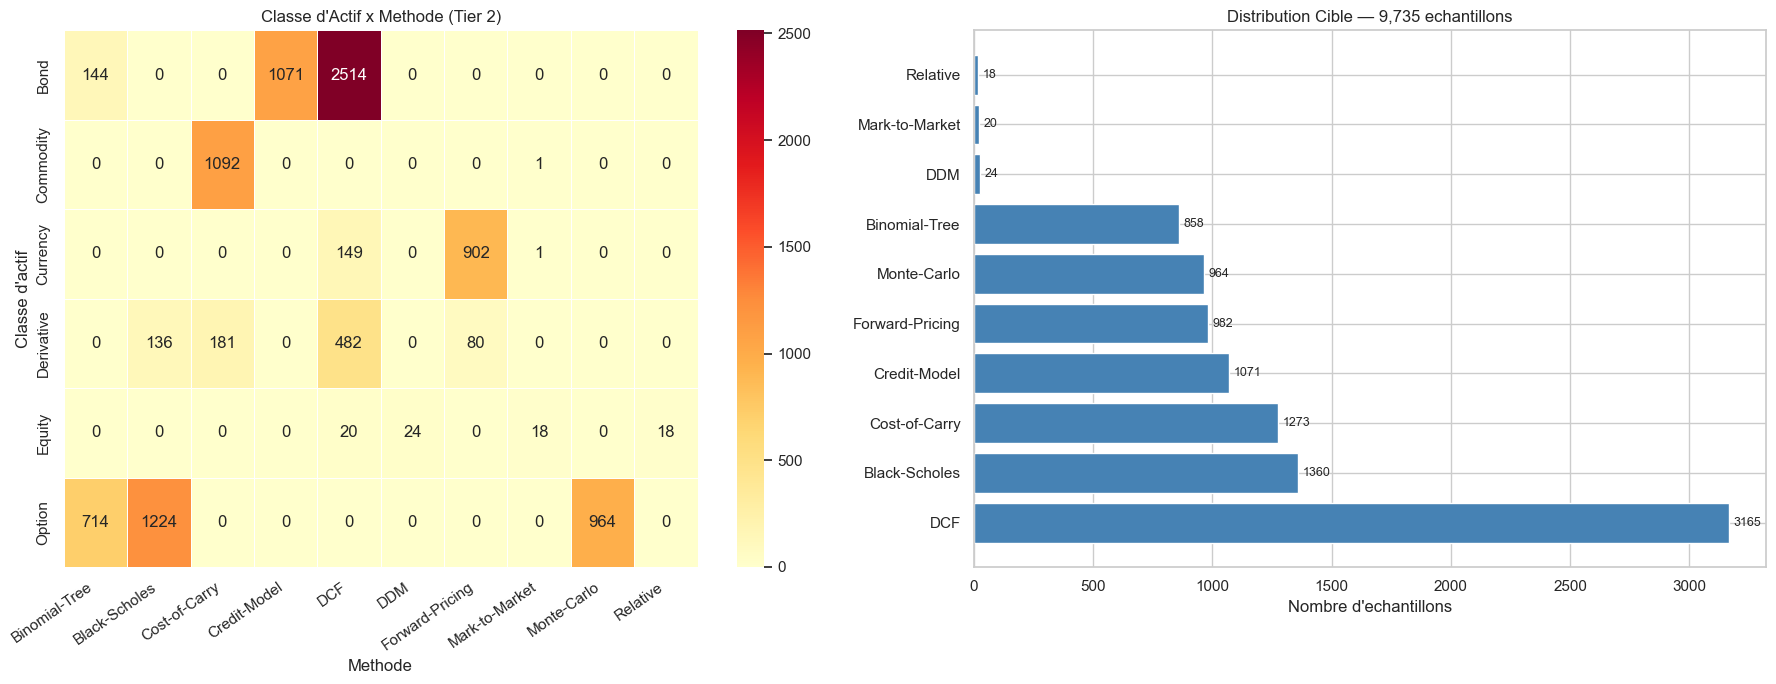


Verification de coherence (0 = OK) :
  BSM + early exercise    : 0
  Path-dep sans MC        : 0
  Option method sans feat : 0

  Toutes les regles sont respectees.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
os.makedirs("reports/figures", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap asset_class x method
ct = pd.crosstab(df_merged["asset_class"], df_merged["recommended_method"])
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=axes[0])
axes[0].set_title("Classe d'Actif x Methode (Tier 2)")
axes[0].set_xlabel("Methode")
axes[0].set_ylabel("Classe d'actif")
plt.sca(axes[0])
plt.xticks(rotation=35, ha="right")

# Distribution de la variable cible
dist = df_merged["recommended_method"].value_counts()
axes[1].barh(dist.index, dist.values, color="steelblue")
axes[1].set_xlabel("Nombre d'echantillons")
axes[1].set_title(f"Distribution Cible — {len(df_merged):,} echantillons")
for i, v in enumerate(dist.values):
    axes[1].text(v + 20, i, f"{v}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("reports/figures/tier2_validation.png", dpi=150, bbox_inches="tight")
plt.show()

# Vérifications de cohérence
print("\nVerification de coherence (0 = OK) :")
v1 = ((df_merged["has_early_exercise"] == 1) & (df_merged["recommended_method"] == "Black-Scholes")).sum()
v2 = ((df_merged["is_path_dependent"] == 1) & (df_merged["recommended_method"] != "Monte-Carlo")).sum()
v3 = ((df_merged["has_options_features"] == 0) &
      (df_merged["recommended_method"].isin(["Black-Scholes", "Binomial-Tree", "Monte-Carlo"])) &
      (df_merged["asset_subclass"] != "Convertible Bond")).sum()

print(f"  BSM + early exercise    : {v1}")
print(f"  Path-dep sans MC        : {v2}")
print(f"  Option method sans feat : {v3}")

if v1 + v2 + v3 == 0:
    print("\n  Toutes les regles sont respectees.")

---
## 9. Inventaire des Fichiers Produits


In [ ]:
print("\n" + "="*70)
print("  FICHIERS PRODUITS PAR CE NOTEBOOK")
print("="*70)

output_files = [
    ("Dataset labelise Tier 2 (CSV)", "processed/labeled_valuation_dataset_tier2.csv"),
    ("Dataset labelise Tier 2 (Parquet)", "processed/labeled_valuation_dataset_tier2.parquet"),
    ("Instruments OpenFIGI", "raw/openfigi/openfigi_instruments.csv"),
    ("Labels depuis OpenFIGI", "processed/labeled_from_openfigi.csv"),
    ("Labels depuis catalogue", "processed/labeled_from_catalog.csv"),
    ("Fondamentaux etendus", "raw/equities_ext/equity_fundamentals_ext.parquet"),
    ("Prix actions etendus", "raw/equities_ext/equity_prices_ext.parquet"),
    ("Prix commodites etendus", "raw/commodities/commodity_prices_ext.parquet"),
    ("Prix forex etendus", "raw/forex/forex_prices_ext.parquet"),
    ("Options chains etendues", "raw/options_ext/options_chains_ext.parquet"),
    ("FRED etendu", "raw/macro_ext/fred_extended.parquet"),
    ("Taux ECB", "raw/ecb/ecb_rates.parquet"),
]

for desc, path in output_files:
    full = DATA_ROOT / path
    if full.exists():
        size = full.stat().st_size / (1024 * 1024)
        print(f"  {desc:<40} {size:>8.2f} MB   {path}")
    else:
        print(f"  {desc:<40} {'—':>8}      {path} (non genere)")

print("\n" + "="*70)
print(f"  Prochaine etape : 03_feature_engineering.ipynb")
print(f"  Utiliser : labeled_valuation_dataset_tier2.csv")
print("="*70)


  FICHIERS PRODUITS PAR CE NOTEBOOK
  Dataset labelise Tier 2 (CSV)                0.64 MB   processed/labeled_valuation_dataset_tier2.csv
  Dataset labelise Tier 2 (Parquet)            0.07 MB   processed/labeled_valuation_dataset_tier2.parquet
  Instruments OpenFIGI                         0.29 MB   raw/openfigi/openfigi_instruments.csv
  Labels depuis OpenFIGI                       0.19 MB   processed/labeled_from_openfigi.csv
  Labels depuis catalogue                      0.03 MB   processed/labeled_from_catalog.csv
  Fondamentaux etendus                         0.03 MB   raw/equities_ext/equity_fundamentals_ext.parquet
  Prix actions etendus                         6.84 MB   raw/equities_ext/equity_prices_ext.parquet
  Prix commodites etendus                      1.28 MB   raw/commodities/commodity_prices_ext.parquet
  Prix forex etendus                           1.41 MB   raw/forex/forex_prices_ext.parquet
  Options chains etendues                      0.59 MB   raw/options_ext/